In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
from seaborn import kdeplot
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import CLASSIC_WF, wrapper

from seaborn import histplot
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

import warnings
warnings.simplefilter('ignore', Warning)


import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
    matplotlib.rcParams['axes.labelsize'] = fontsize
    matplotlib.rcParams['legend.fontsize'] = fontsize

Text(0, 0.5, 'CNV Proportion')

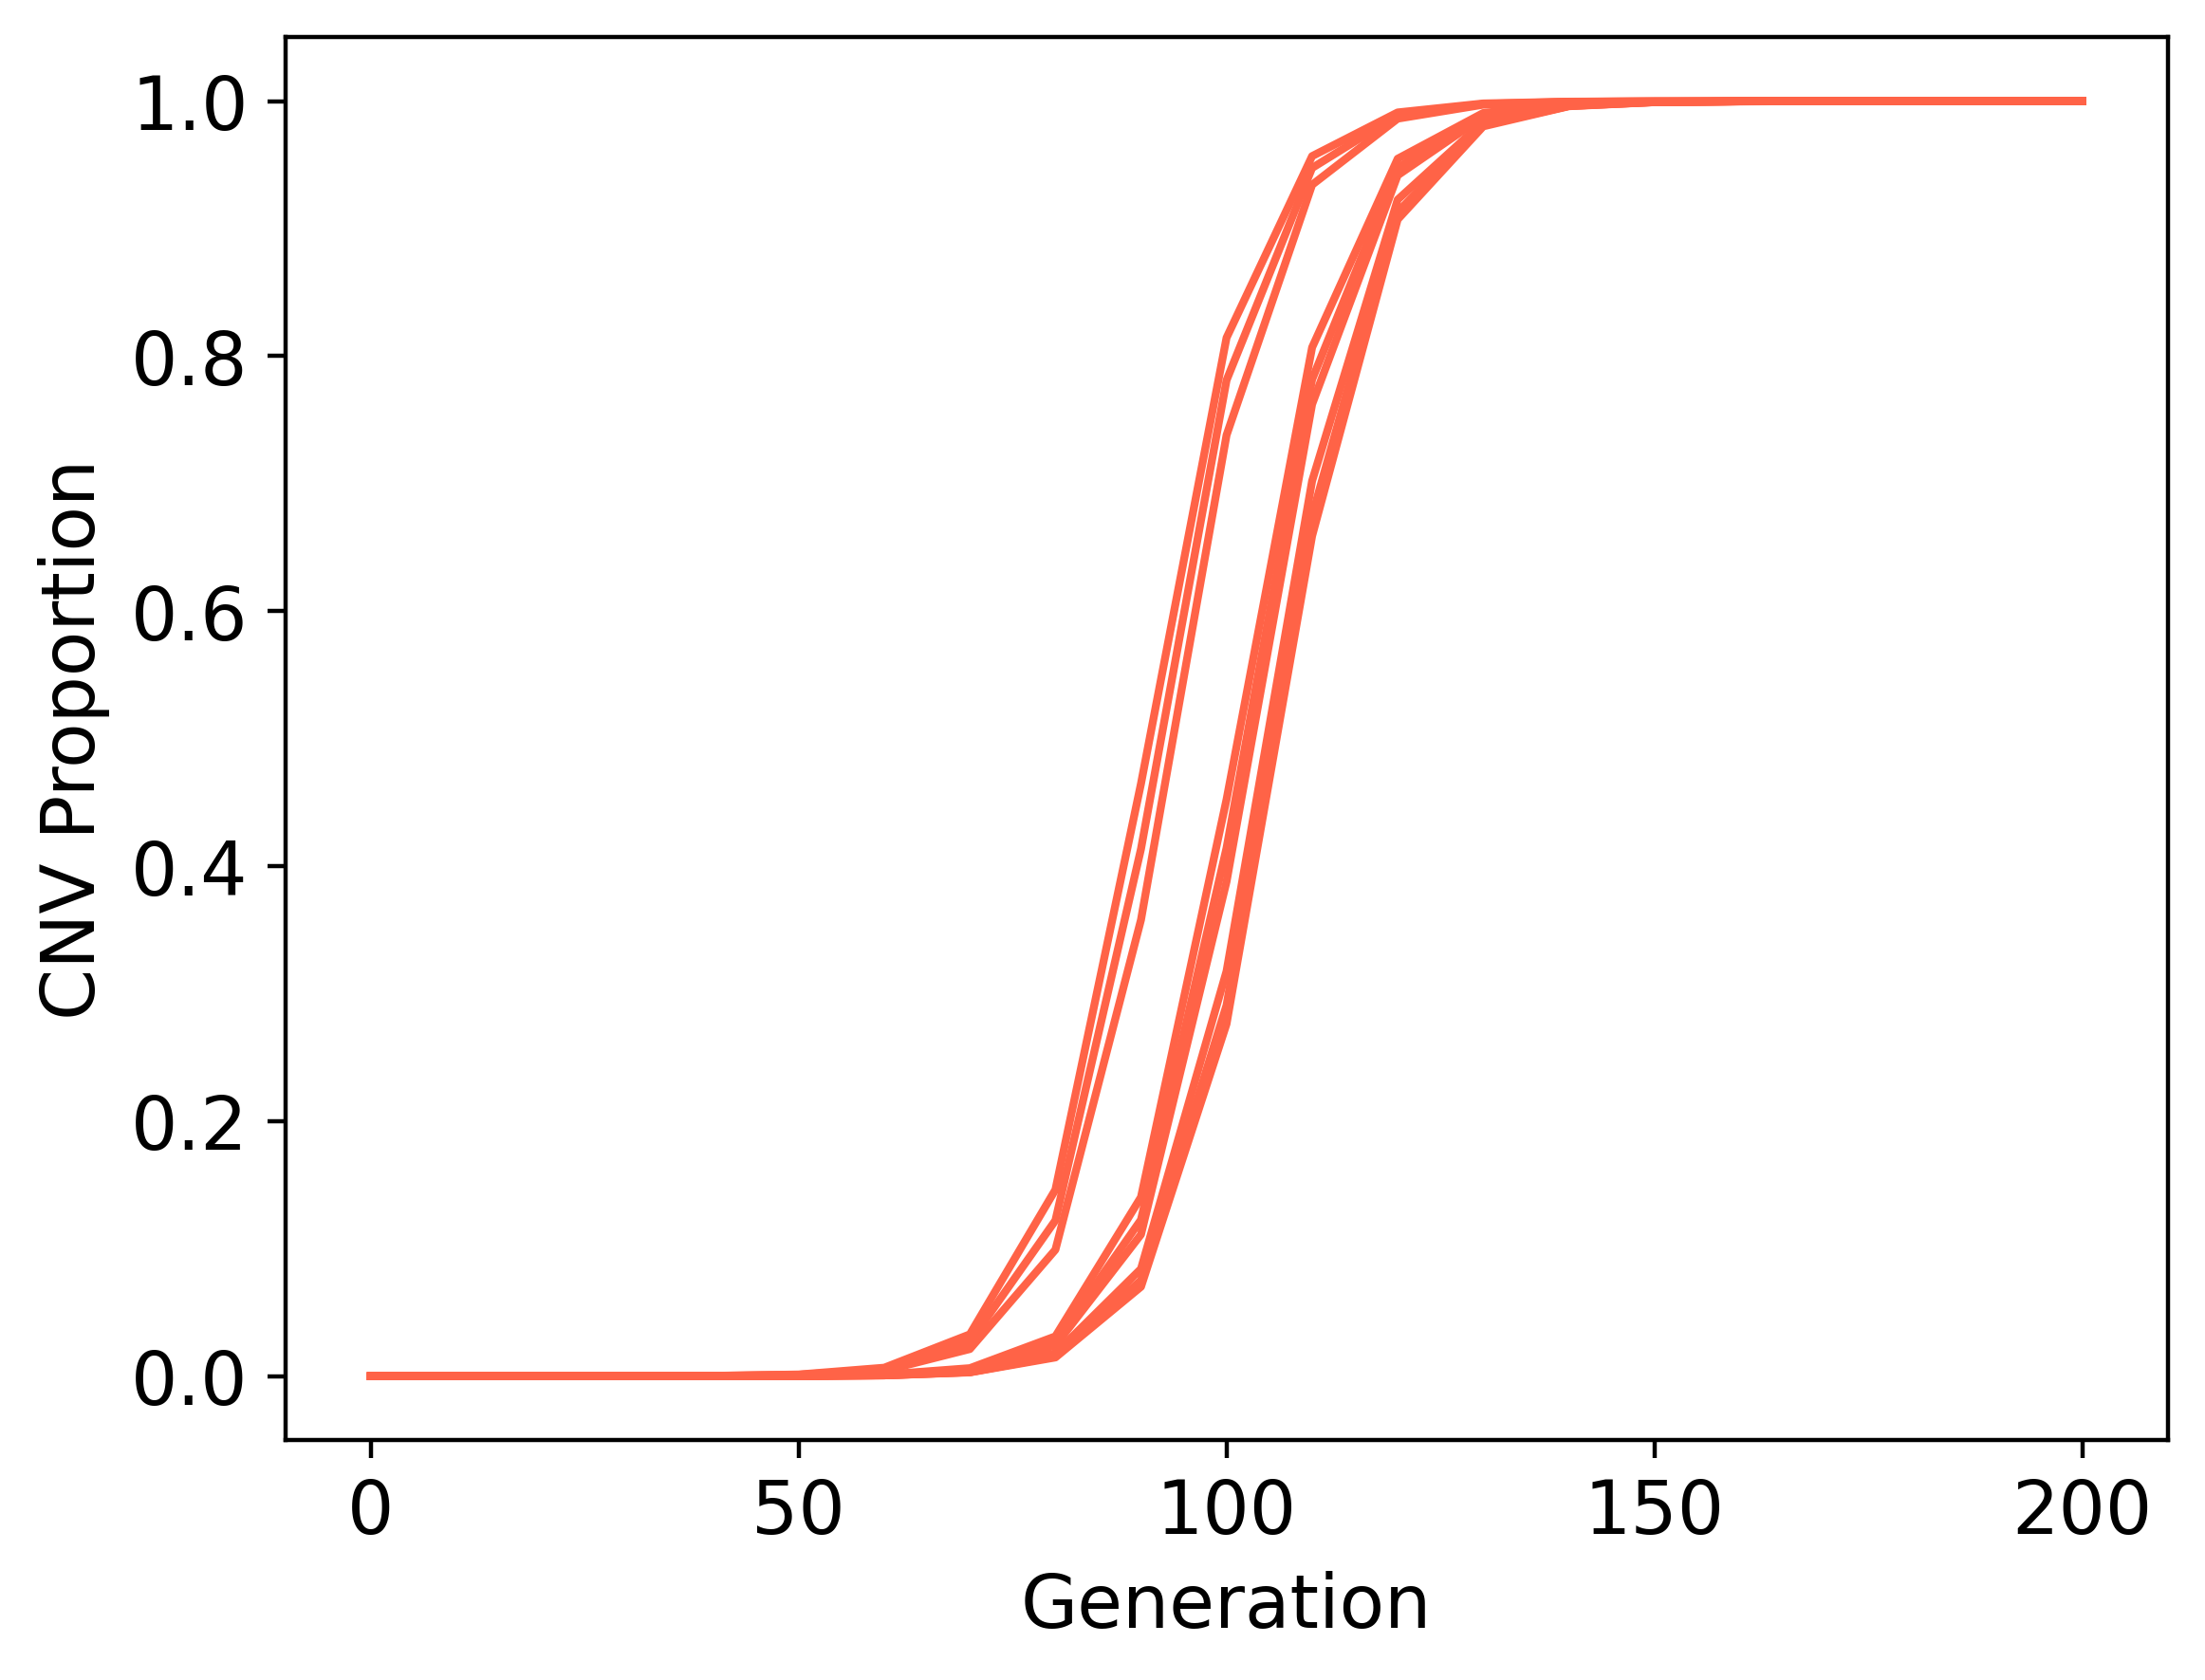

In [7]:
from inference_utils import get_prior

prior = get_prior('CLASSIC_WF')
th = prior.sample((1,)).squeeze() # Example parameters in log10 space

generation = torch.arange(0,201,10)
X = wrapper(CLASSIC_WF,parameters=th, reps=10)
change_font(14)

for i in range(len(X)):
    plt.plot(generation,X[i], color='tomato', label='regular' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')

Text(0, 0.5, 'CNV Proportion')

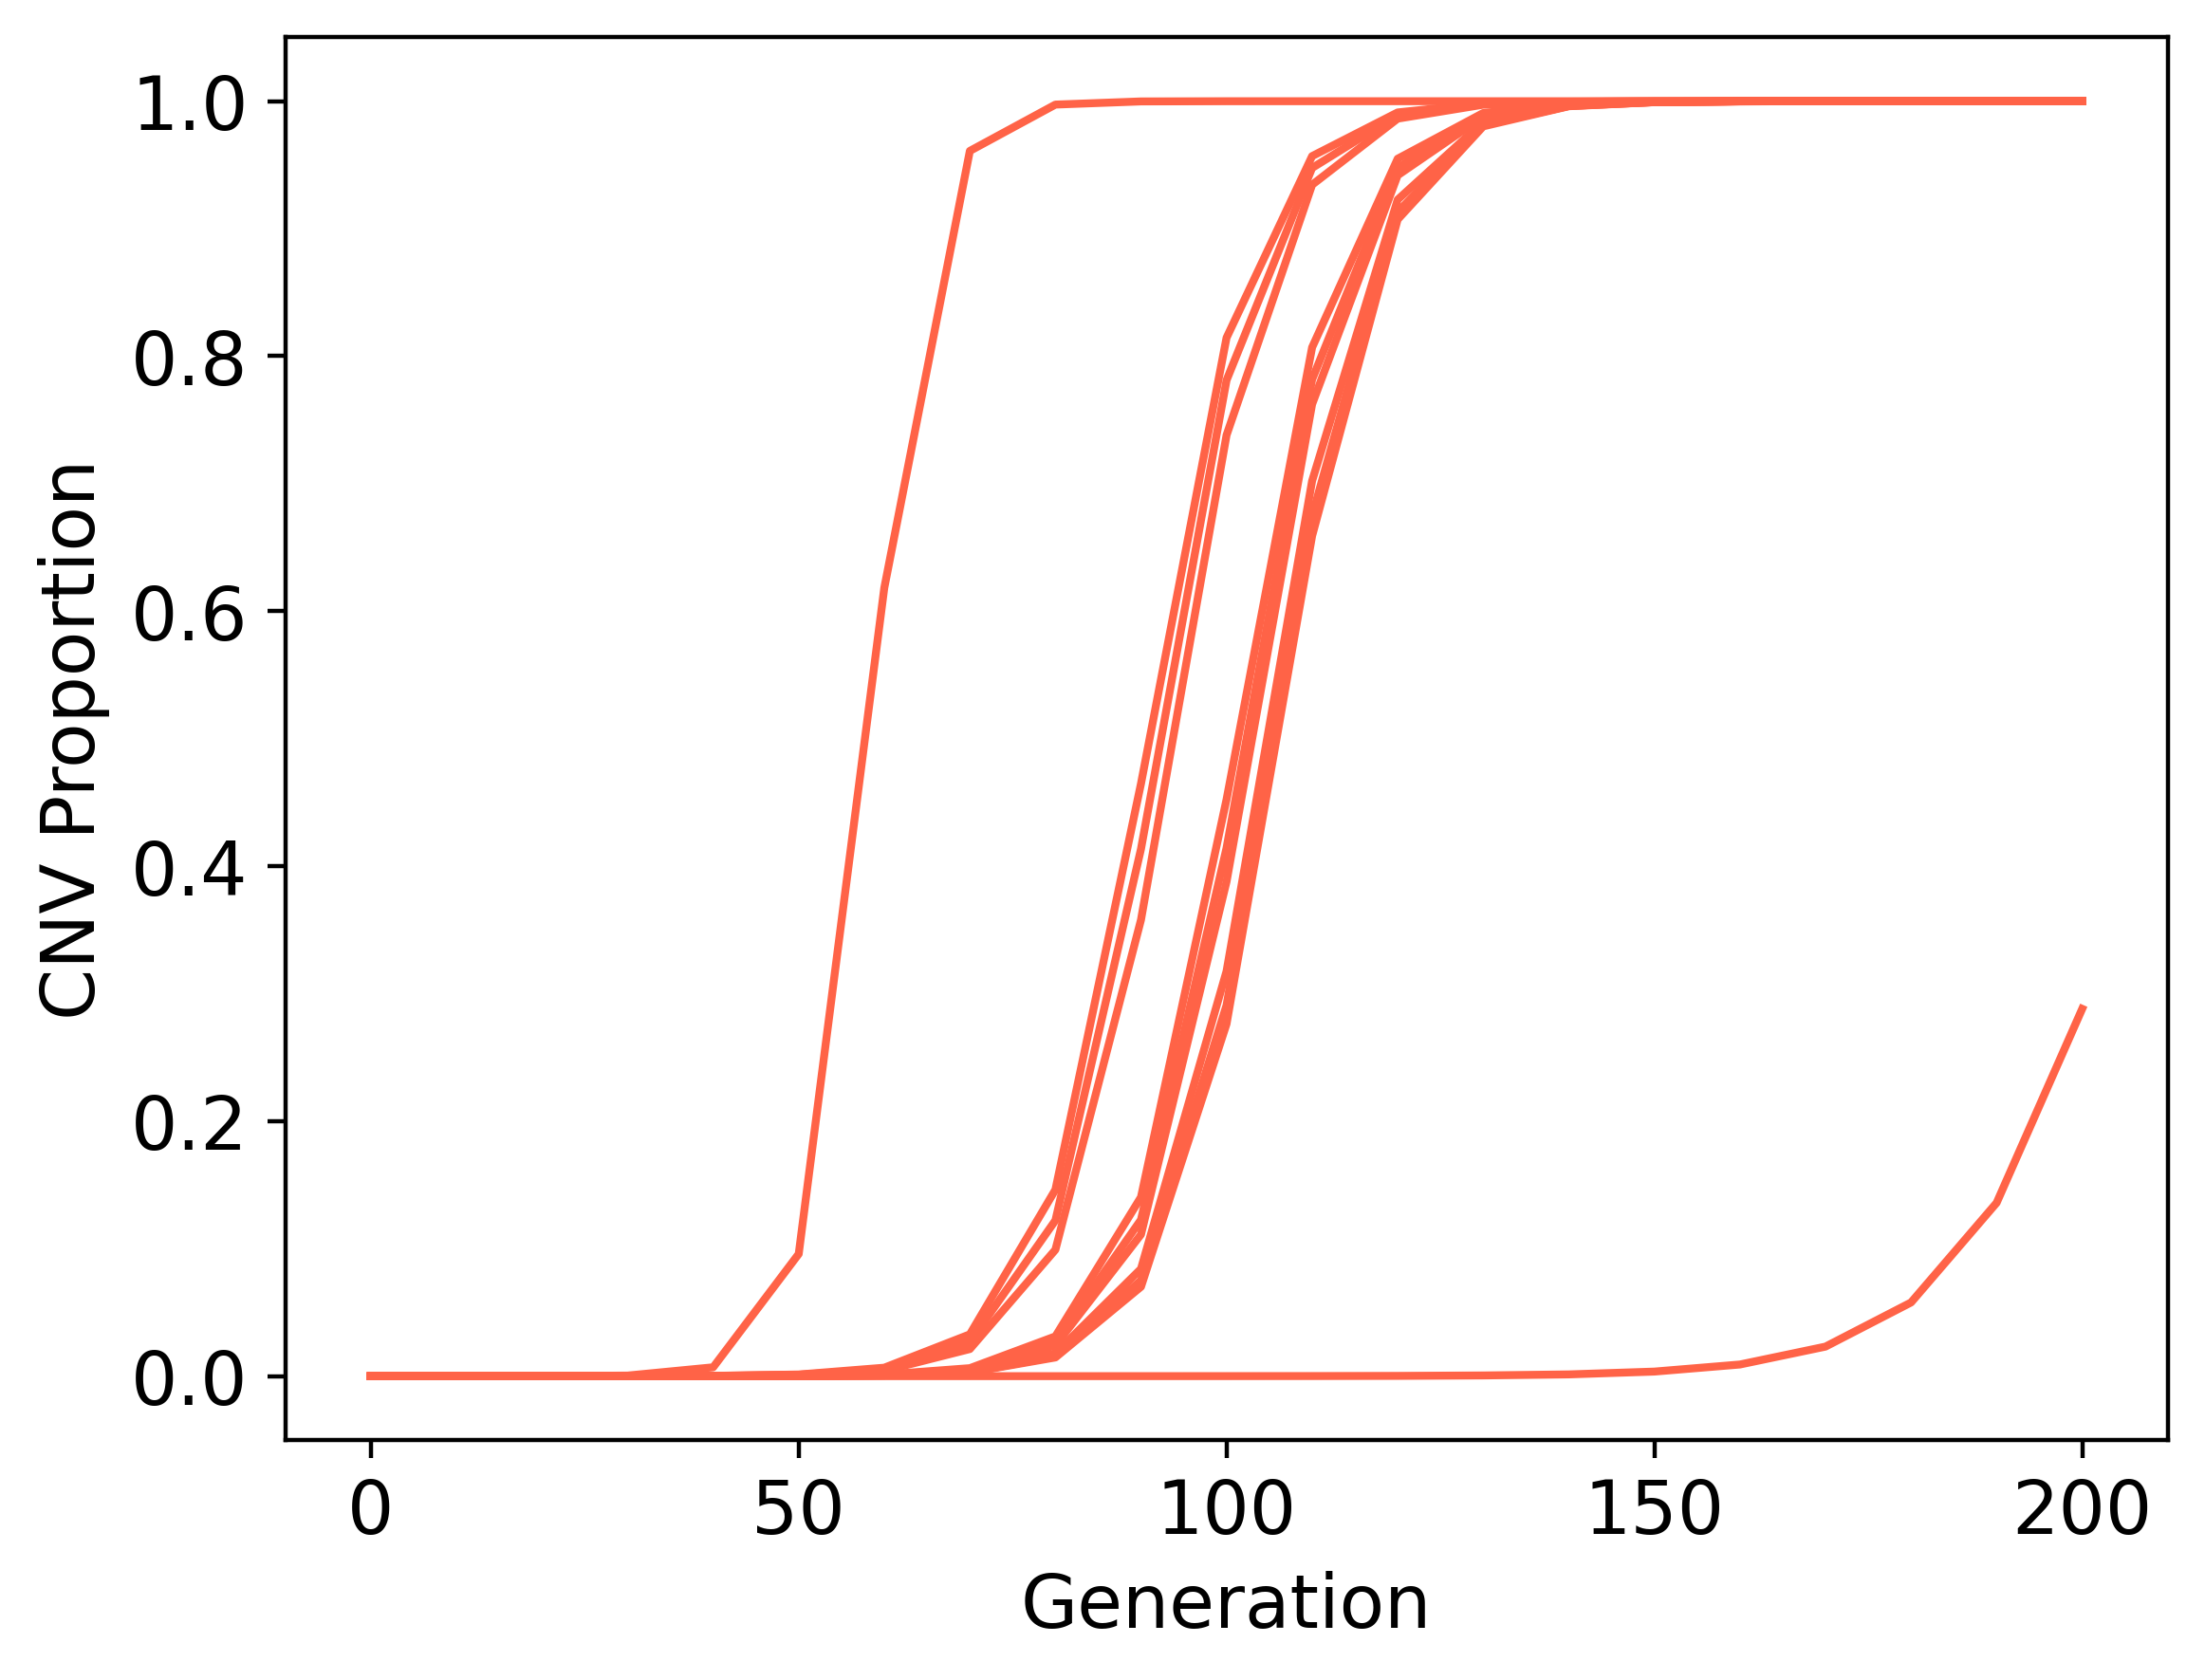

In [8]:
x_outlier = CLASSIC_WF(th+0.25).reshape(1,-1)
x_oo = CLASSIC_WF(th-0.25).reshape(1,-1)
X_o = torch.cat([X,x_outlier, x_oo])
for i in range(len(X_o)):
    plt.plot(generation,X_o[i], color='tomato')
plt.xlabel('Generation')
plt.ylabel('CNV Proportion')

Sampling:   0%|          | 0/200 [00:00<?, ?it/s]


RuntimeError: cannot reshape tensor of 0 elements into shape [0, -1] because the unspecified dimension size -1 can be any value and is ambiguous

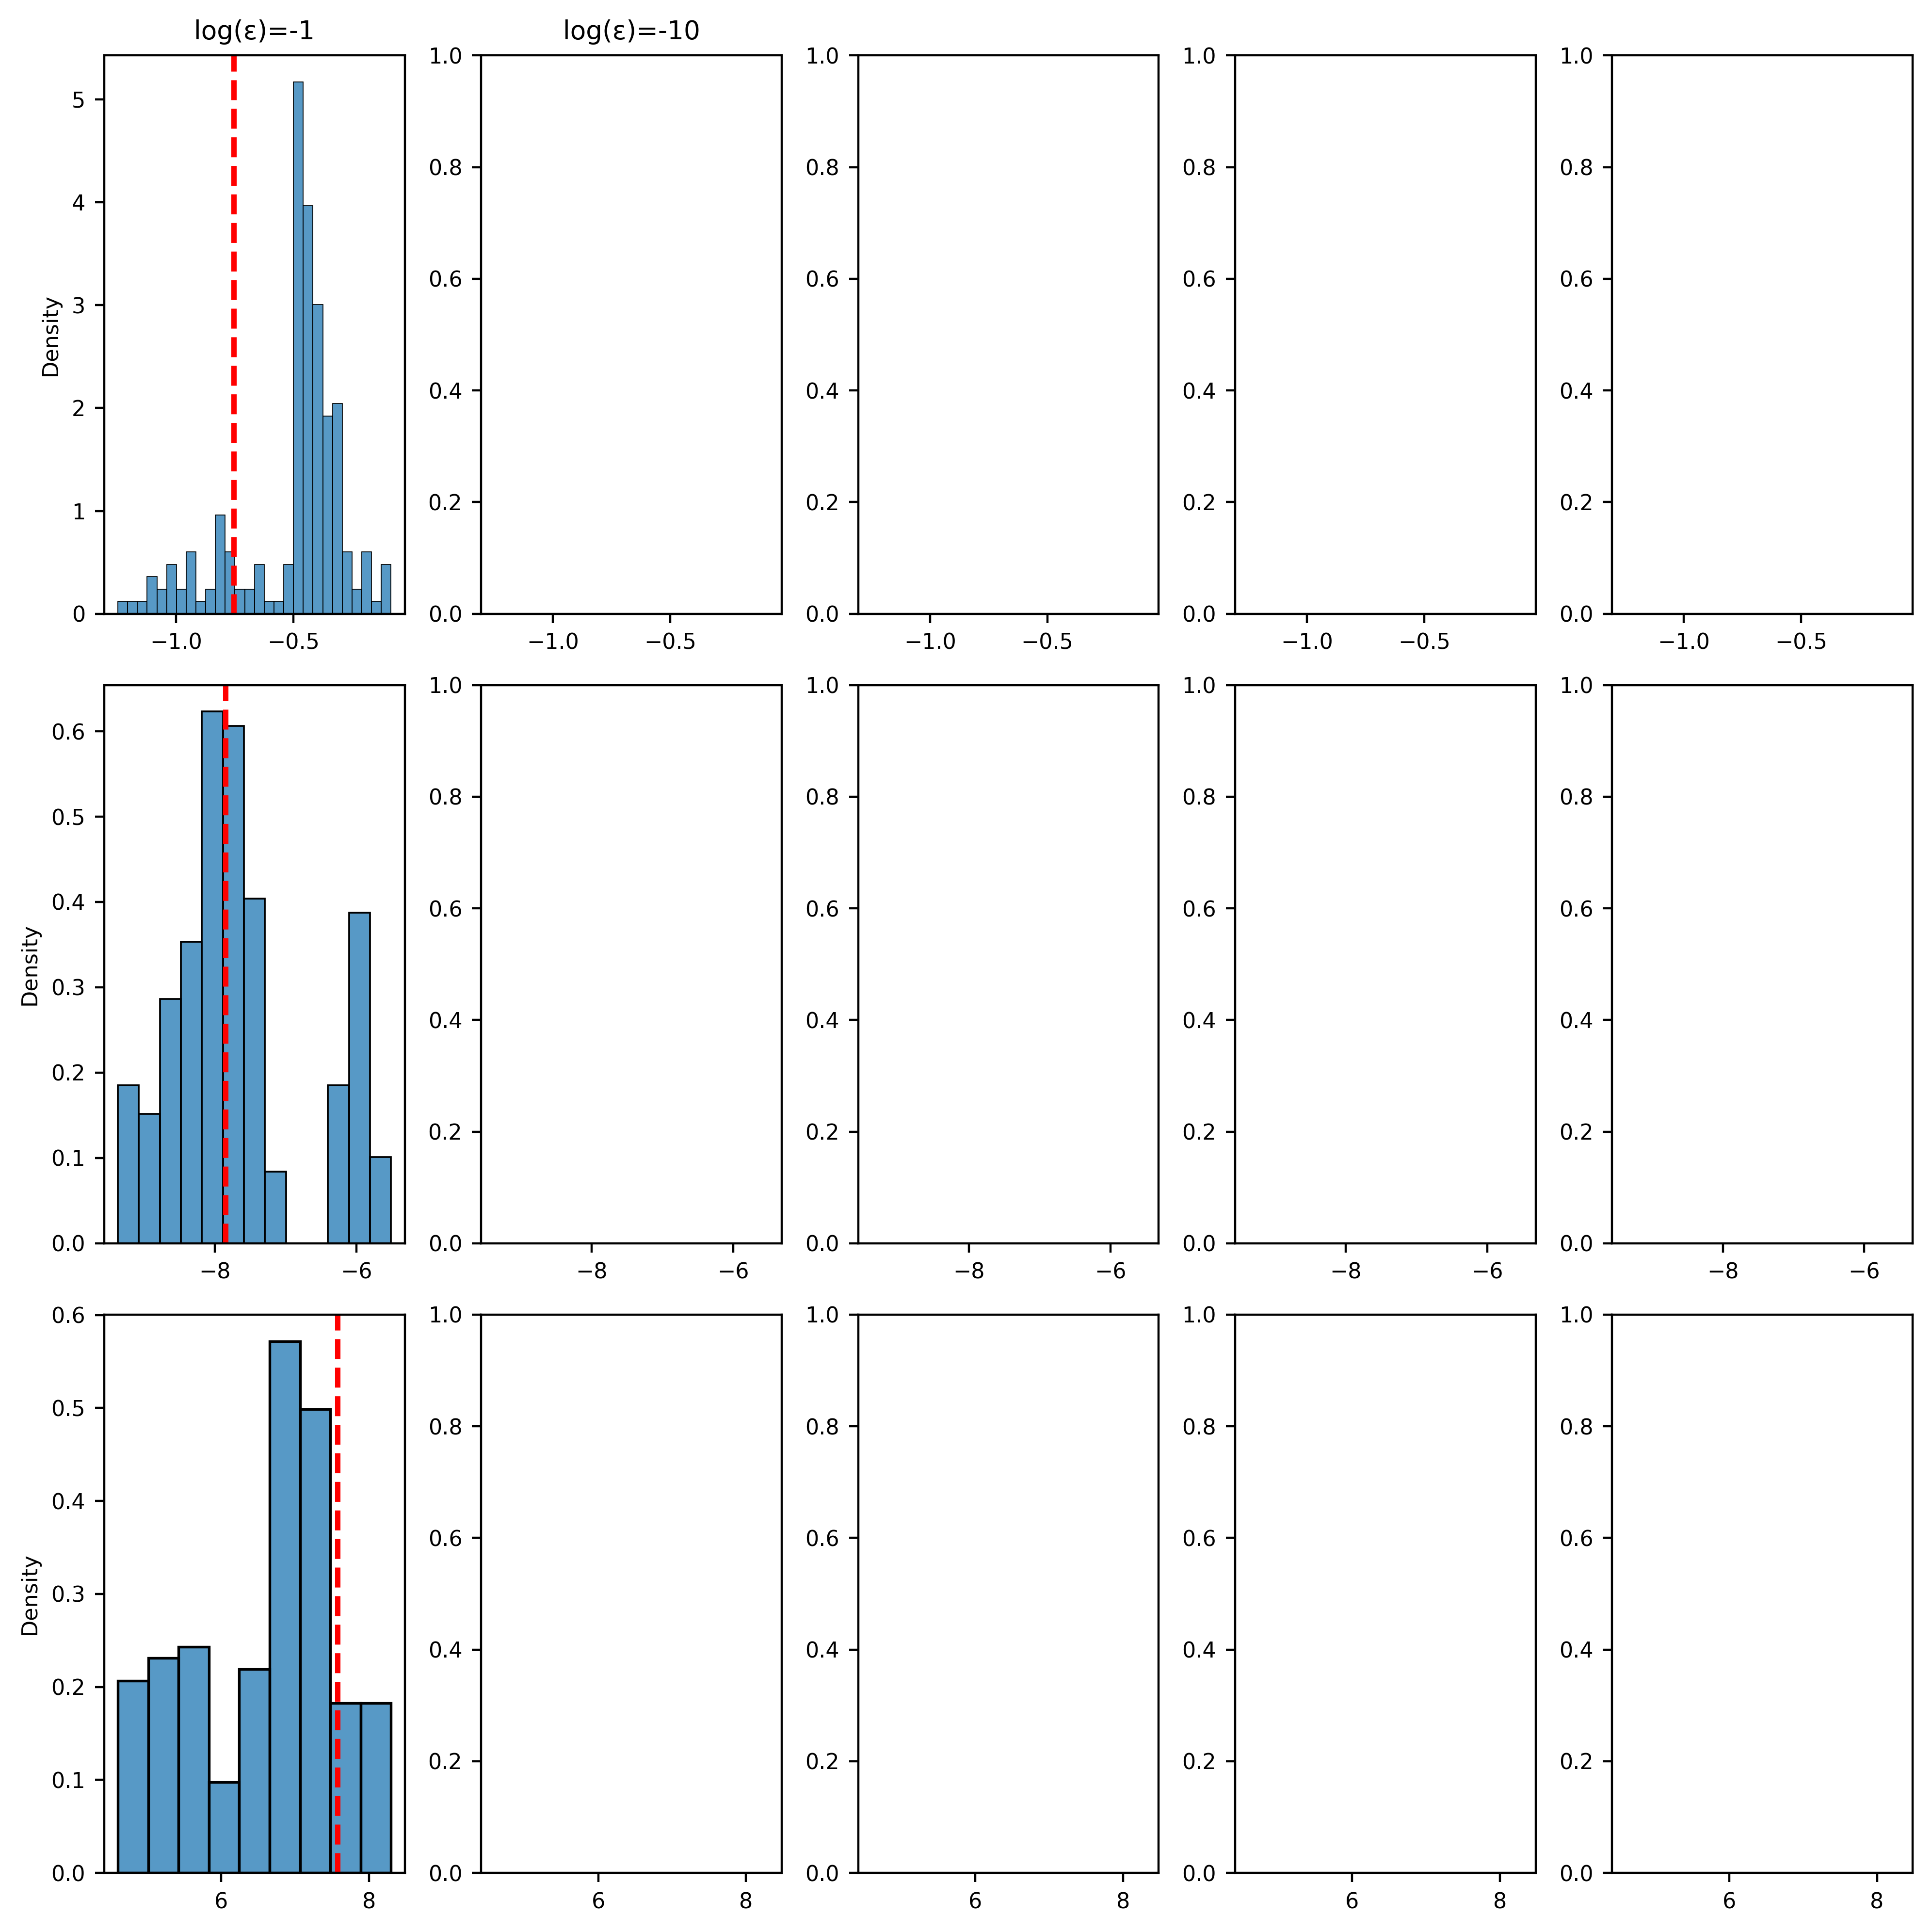

In [9]:
from inference_utils import get_prior
prior = get_prior('CLASSIC_WF')

posterior = pickle.load(open('posterior_singles.pkl', 'rb'))

change_font(8)
fig, ax = plt.subplots(3,5, tight_layout=True, figsize=(10,10), sharex='row')
for i in range(5):
    epsilon = -10**i
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X_o, posterior, 1, epsilon)
    op.get_log_C()
    samps = op.sample_multimodal(200)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density')
        ax[j,i].axvline(th[j], color='red', lw=2, ls='--')

Rejection Sampling: 10000it [00:00, 113600.59it/s]         
Rejection Sampling: 102it [00:04, 22.30it/s]                        
Rejection Sampling: 105it [00:03, 33.33it/s]                        
Rejection Sampling: 102it [00:03, 28.13it/s]                        
Rejection Sampling: 104it [00:02, 35.64it/s]                        
Rejection Sampling: 10000it [00:00, 76960.98it/s]          
Rejection Sampling: 101it [00:03, 25.38it/s]                        
Rejection Sampling: 100%|██████████| 100/100 [00:04<00:00, 21.59it/s]
Rejection Sampling: 110it [00:00, 176.85it/s]                        
Rejection Sampling: 108it [00:01, 80.58it/s]                        


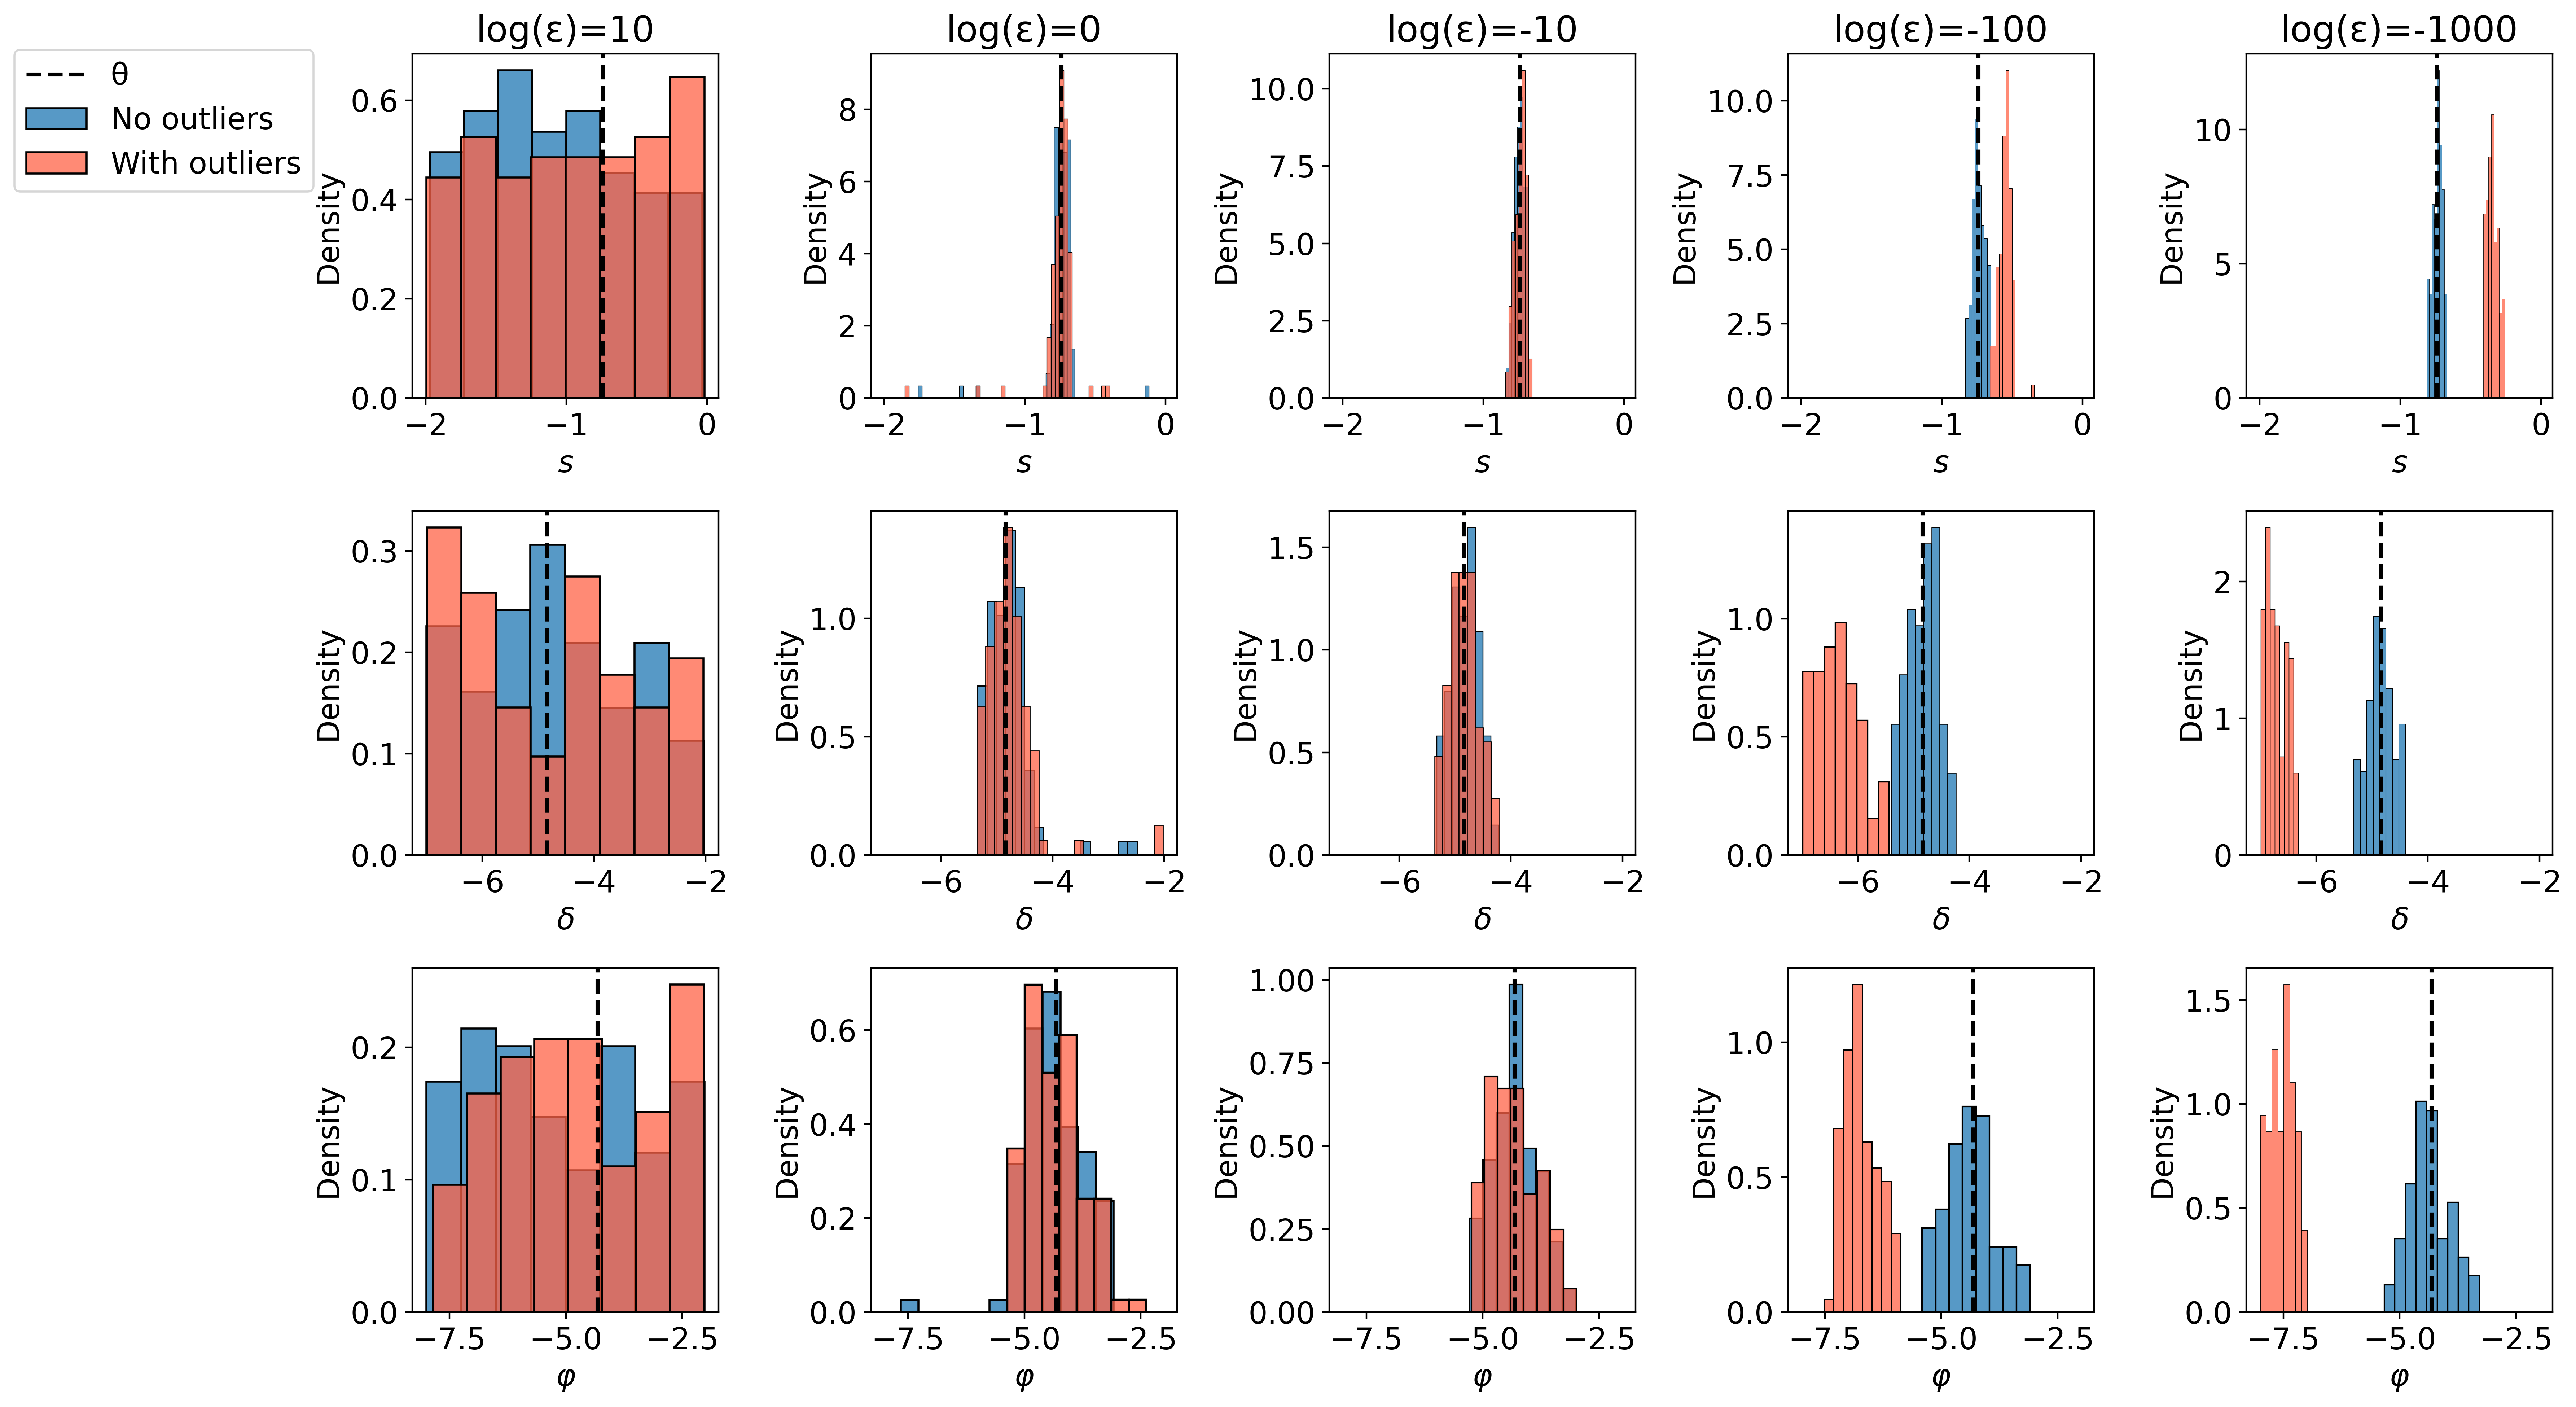

In [ ]:
change_font(15)
fig, ax = plt.subplots(3,5, tight_layout=True, figsize=(18,10), sharex='row')
for l in range(5):
    ax[0,l].set_xlabel('$s$')
    ax[1,l].set_xlabel('$δ$')
    ax[2,l].set_xlabel('$φ$')
    
epsilons = [10,0,-10,-100,-1000]

for i in range(len(epsilons)):
    epsilon = epsilons[i]
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X, posterior_chuong, 1, epsilon)
    op.get_log_C()
    samps = op.sample(100)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density', label = 'No outliers' if i*j==0 else '')
        
for i in range(len(epsilons)):
    epsilon = epsilons[i]
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X_o, posterior_chuong, 1, epsilon)
    op.get_log_C()
    samps = op.sample(100)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density', color='tomato', label = 'With outliers' if i*j==0 else '')
        ax[j,i].axvline(th[j], color='k', lw=2, ls='--', label='θ' if i*j==0 else '')

ax[0,0].legend(loc=(-1.3,0.6))